In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

In [4]:
df = pd.read_csv(r"C:\Users\Amey\Downloads\archive (1)\Customer Purchase Data.csv")
print(df.head())

   Number  Age       Income  Spending_Score  Membership_Years  \
0       1   56  61350.84215    12372.864450                15   
1       2   46  53777.18224    11001.604230                10   
2       3   32  39460.32263     8007.385018                19   
3       4   60  66672.12210    13526.548370                12   
4       5   38  44459.08553     9059.304083                 9   

   Purchase_Frequency  Last_Purchase_Amount  
0           77.685590           6232.122440  
1           51.858351           5545.849698  
2           98.166371           4054.645293  
3           62.530976           6815.544393  
4           46.470533           4617.833484  


In [10]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1362 entries, 0 to 1361
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Number                1362 non-null   int64  
 1   Age                   1362 non-null   int64  
 2   Income                1362 non-null   float64
 3   Spending_Score        1362 non-null   float64
 4   Membership_Years      1362 non-null   int64  
 5   Purchase_Frequency    1362 non-null   float64
 6   Last_Purchase_Amount  1362 non-null   float64
dtypes: float64(4), int64(3)
memory usage: 74.6 KB


In [7]:
df.describe()

,Number,Age,Income,Spending_Score,Membership_Years,Purchase_Frequency,Last_Purchase_Amount
count,1362.000000,1362.000000,1362.000000,1362.000000,1362.000000,1362.000000,1362.000000
mean,681.500000,43.251836,48317.193784,9765.372547,9.513950,49.551706,4931.689546
std,393.319844,12.533236,12648.638324,2531.133100,5.417624,27.074169,1266.894447
min,1.000000,18.000000,19946.675740,4064.177336,1.000000,4.876052,2057.551913
25%,341.250000,33.000000,38532.229703,7830.921337,5.000000,26.560455,3962.190531
50%,681.500000,43.000000,48758.233625,9850.200389,9.000000,47.729713,4972.893731
75%,1021.750000,54.000000,58579.901010,11810.345793,14.000000,72.135292,5962.991091
max,1362.000000,64.000000,73182.569800,14791.611800,19.000000,99.492184,7519.376995


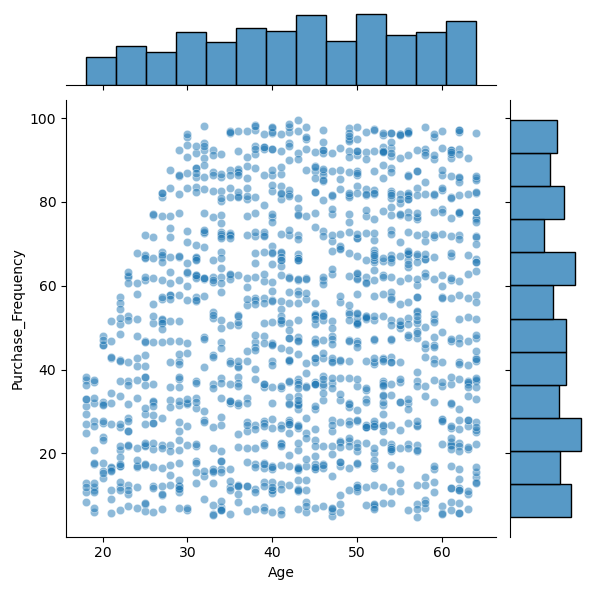

In [12]:
sns.jointplot(x='Age', y= 'Purchase_Frequency' , data= df, alpha = 0.5 )

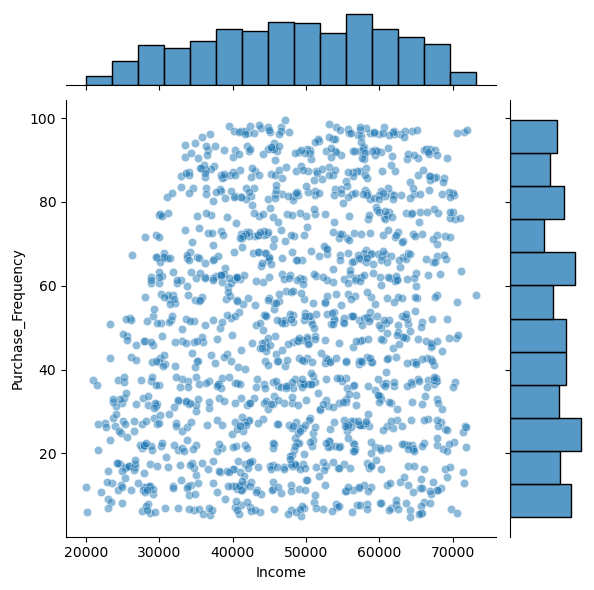

In [13]:
sns.jointplot(x='Income', y= 'Purchase_Frequency' , data= df, alpha = 0.5 )

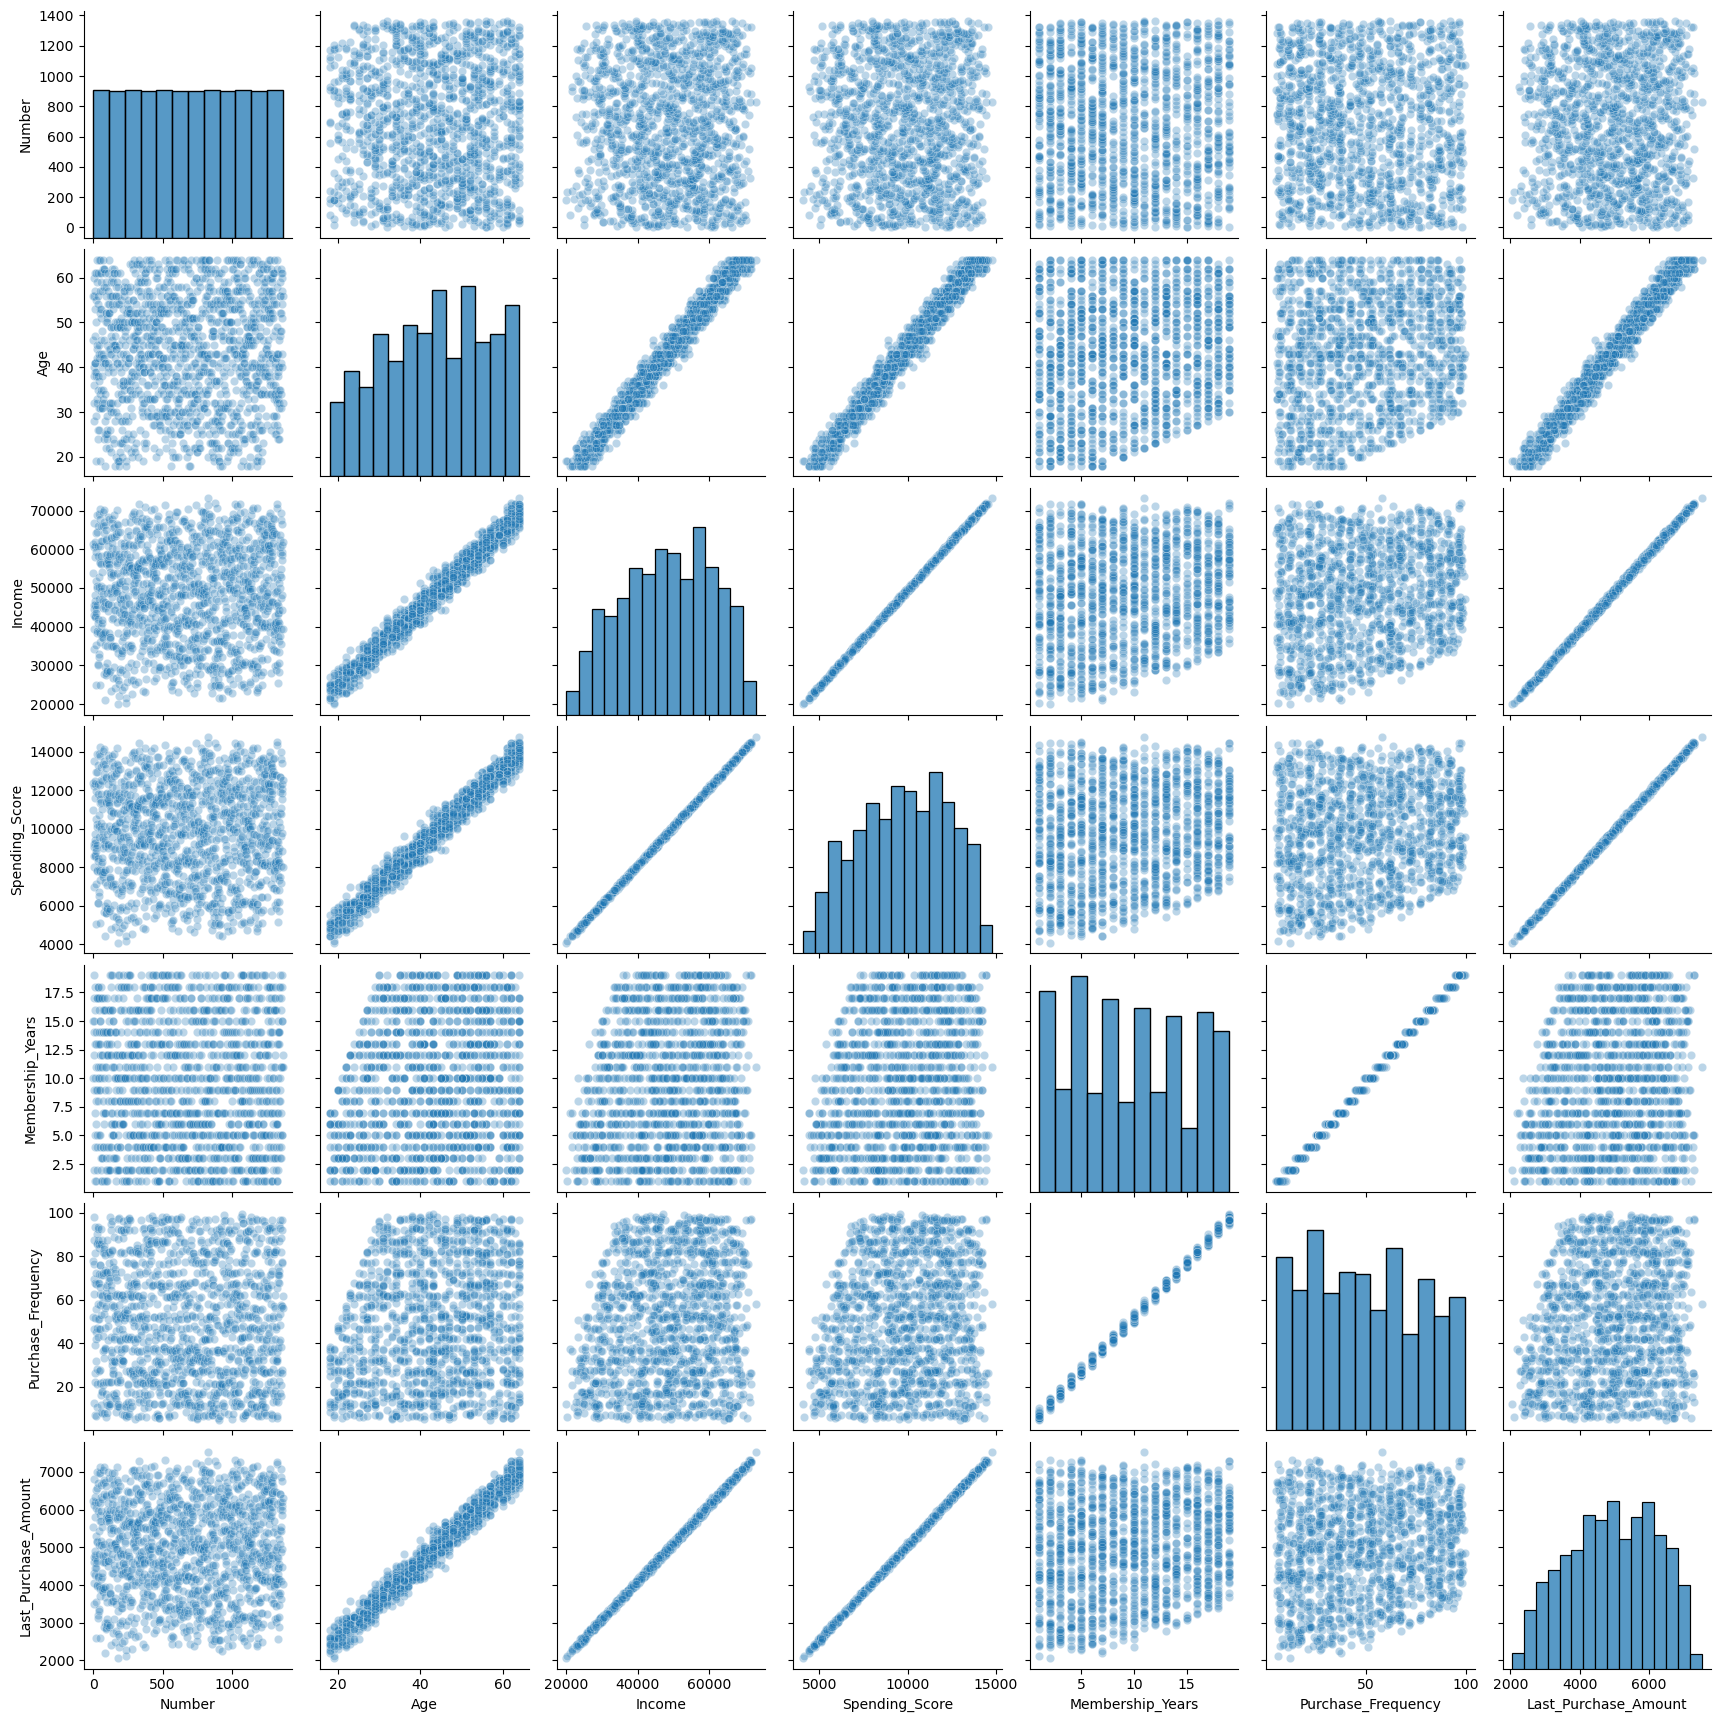

In [15]:
sns.pairplot(df, kind = 'scatter', plot_kws={'alpha':0.3})

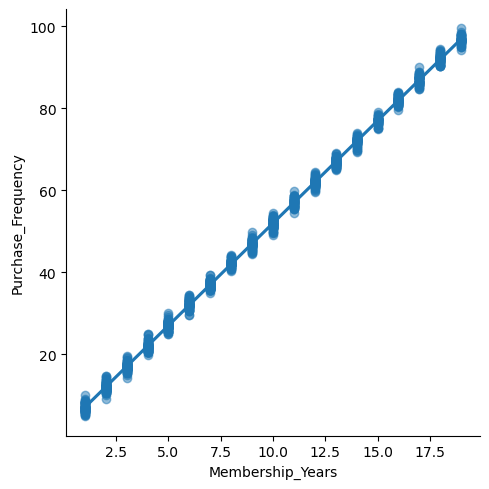

In [17]:
sns.lmplot(x='Membership_Years'
           ,y='Purchase_Frequency'
           ,data= df
           , scatter_kws={'alpha':0.5})

In [18]:
from sklearn.model_selection import train_test_split

In [25]:
X = df[['Age','Income','Spending_Score','Membership_Years','Last_Purchase_Amount']]
y = df['Purchase_Frequency']

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [27]:
X_test

,Age,Income,Spending_Score,Membership_Years,Last_Purchase_Amount
1283,57,63758.35260,12766.695650,7,6391.129021
387,47,48263.59920,9833.991433,7,5016.512905
379,49,51347.15863,10318.780250,10,5233.982316
1211,26,31396.97064,6428.312625,11,3255.456872
832,51,55562.75858,11219.741120,7,5700.649486
...,...,...,...,...,...
238,29,37902.06860,7735.919600,2,3894.344578
390,36,39960.29322,8048.865415,4,4075.438449
83,61,66308.81455,13388.751920,9,6740.528057
670,48,54818.43233,11043.849220,16,5562.655808


In [41]:
from sklearn.linear_model import LinearRegression


In [42]:
lm = LinearRegression()

In [43]:
lm.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [38]:
print(X_train.shape)
print(y_train.shape)

(1089, 5)
(273,)


In [44]:
lm.coef_

array([-1.41603948e-02,  4.96964457e-05,  4.97255915e-05,  4.98937880e+00,
       -4.85102273e-04])

In [46]:
cdf = pd.DataFrame(lm.coef_,X.columns, columns= ['coef'])
print(cdf)

                          coef
Age                  -0.014160
Income                0.000050
Spending_Score        0.000050
Membership_Years      4.989379
Last_Purchase_Amount -0.000485


In [47]:
predictions = lm.predict(X_test)
predictions

array([76.88189651,  7.16608681, 12.1301739 , 22.10456795, 81.87571186,
       36.9050355 , 26.95872635, 46.9169795 , 32.11684044, 47.04522666,
       27.08465024, 76.86585758,  7.08438846, 47.02359069, 42.04780483,
       31.97443201, 52.00262379, 61.90701396, 12.13801405, 81.88905017,
       71.94721494, 61.9880355 , 46.98149126, 12.04913739, 51.96975224,
       61.95742545, 57.03376973, 96.82456257, 76.95322978, 86.81906734,
       37.05963068, 76.92289736, 22.08751884, 61.98472113, 86.86864569,
       32.0251535 , 27.10190071,  7.06935457, 81.99728478, 22.01569698,
       47.06539155, 76.91677782, 17.20418914, 61.97949579, 91.88152144,
       62.01707474, 12.12268412, 61.88167312, 41.95566826, 96.9234229 ,
       56.95129547, 66.86931082, 22.14514891, 91.94001323, 61.924299  ,
       36.98426848, 62.05867027, 66.90119775, 61.89878729, 61.92014236,
       42.02496796, 37.09828733, 96.84570826, 12.07964922, 31.98932346,
       91.9607856 , 51.96844739, 22.02032222, 27.09783882, 66.94

Text(0.5, 1.0, 'evalution of our LM model')

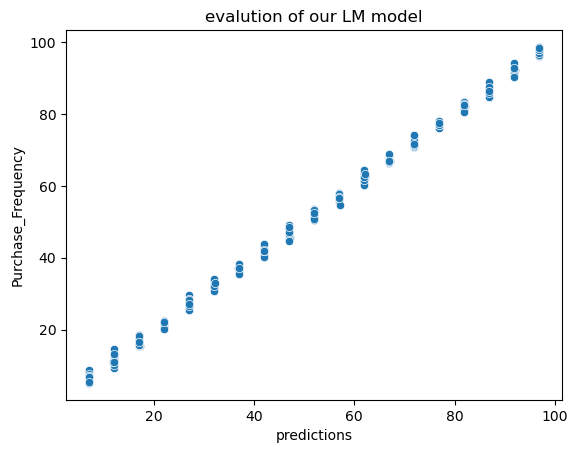

In [49]:
sns.scatterplot(x=predictions,y=y_test)
plt.xlabel("predictions") 
plt.title("evalution of our LM model")

In [50]:
from sklearn.metrics import mean_absolute_error,mean_squared_error
import math

In [51]:
print("mean absolute error:", mean_absolute_error(y_test,predictions))
print("mean squared error:", mean_squared_error(y_test,predictions))
print("RMSE:", math.sqrt(mean_squared_error(y_test,predictions)))

mean absolute error: 0.7817384718715883
mean squared error: 0.9847799602881926
RMSE: 0.9923608014669829


In [52]:
residuals = y_test-predictions
residuals

51     -0.909300
1102    1.334188
1314    1.336609
514    -0.868755
1252    1.494390
          ...   
573    -0.415040
243    -0.100906
947    -1.304436
638     0.551193
739    -0.067876
Name: Purchase_Frequency, Length: 273, dtype: float64

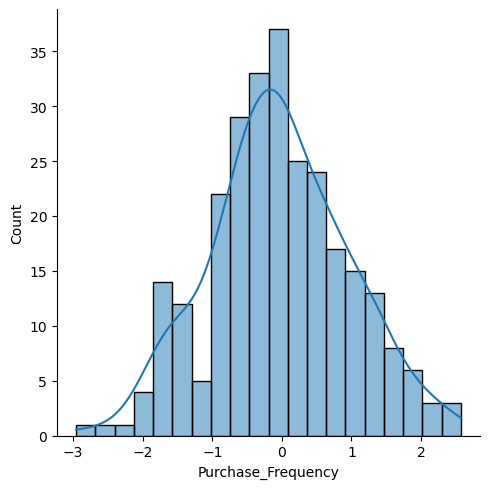

In [53]:
sns.displot(residuals,bins=20,kde=True)

In [54]:
import pylab
import scipy.stats as stats 

<function matplotlib.pyplot.show(close=None, block=None)>

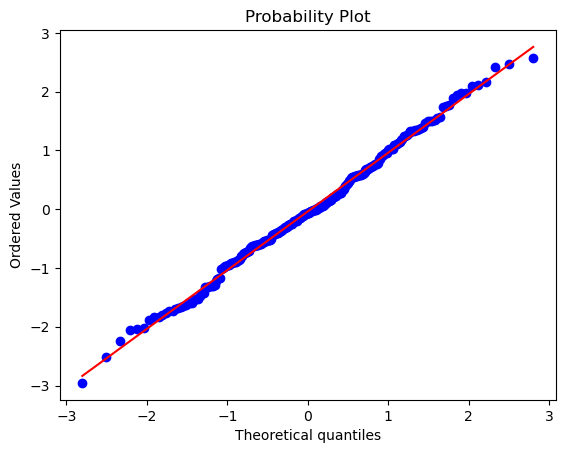

In [55]:
stats.probplot(
    residuals,
    dist='norm',
    plot=pylab
)

pylab.show